In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models

print("PyTorch:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.13.0+cpu
Device: cpu


## CIFAR-10 Dataset and Data Augmentation

The CIFAR-10 dataset contains 10 classes of images.

Data augmentation techniques such as random horizontal flipping and rotation are applied to the training images to improve the model's ability to generalize.

In [2]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

print("Train dataset:", len(train_dataset))
print("Test dataset:", len(test_dataset))

100.0%


Train dataset: 50000
Test dataset: 10000


## CIFAR-10 Dataset and Data Augmentation

The CIFAR-10 dataset contains 10 classes of images.

Data augmentation techniques such as random horizontal flipping and rotation are applied to the training images to improve the model's ability to generalize.

In [3]:
from torch.utils.data import Subset

train_subset = Subset(train_dataset, range(5000))
test_subset = Subset(test_dataset, range(1000))

print("Training subset:", len(train_subset))
print("Testing subset:", len(test_subset))

Training subset: 5000
Testing subset: 1000


## DataLoaders

DataLoaders divide the dataset into batches for efficient model training and evaluation.

In [4]:
train_loader = torch.utils.data.DataLoader(
    train_subset,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

test_loader = torch.utils.data.DataLoader(
    test_subset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 79
Testing batches: 16


## Pretrained ResNet18

A pretrained ResNet18 model is used for transfer learning.
The final classification layer is replaced to classify the 10 CIFAR-10 classes.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

print("Model: ResNet18")
print("Device:", device)
print("Classes:", 10)

Model: ResNet18
Device: cpu
Classes: 10


## Loss Function and Optimizer

Cross-Entropy Loss is used for multi-class classification.
The Adam optimizer is used to update the model parameters.

In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")

Loss: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


## Training Configuration

The model is trained for 2 epochs to keep training time manageable on a CPU.

In [7]:
num_epochs = 2

train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

print("Epochs:", num_epochs)

Epochs: 2


## Model Training

The ResNet18 model is trained on the selected CIFAR-10 training subset.
Training and testing performance are recorded after each epoch.

In [8]:
for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_subset)
    train_accuracy = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_loss = test_loss / len(test_subset)
    test_accuracy = test_correct / test_total

    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Accuracy: {train_accuracy:.4f} "
        f"Test Loss: {test_loss:.4f} "
        f"Test Accuracy: {test_accuracy:.4f}"
    )

Epoch [1/2] Train Loss: 0.9942 Train Accuracy: 0.6578 Test Loss: 0.9031 Test Accuracy: 0.6800
Epoch [2/2] Train Loss: 0.6394 Train Accuracy: 0.7766 Test Loss: 0.7798 Test Accuracy: 0.7330


## Saving the Trained Model

The trained ResNet18 model is saved as a PyTorch `.pth` file for future inference.

In [9]:
torch.save(model.state_dict(), "resnet18_cifar10.pth")

print("Model saved successfully!")

Model saved successfully!


## Evaluation Metrics

The model is evaluated using precision, recall, F1-score, and a confusion matrix.

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

    airplane       0.79      0.64      0.71       103
  automobile       0.81      0.89      0.84        89
        bird       0.68      0.75      0.71       100
         cat       0.70      0.38      0.49       103
        deer       0.71      0.74      0.73        90
         dog       0.60      0.69      0.64        86
        frog       0.83      0.71      0.77       112
       horse       0.64      0.91      0.75       102
        ship       0.76      0.92      0.83       106
       truck       0.88      0.71      0.78       109

    accuracy                           0.73      1000
   macro avg       0.74      0.73      0.73      1000
weighted avg       0.74      0.73      0.73      1000



## Confusion Matrix

A confusion matrix is used to visualize the classification performance across all CIFAR-10 classes.

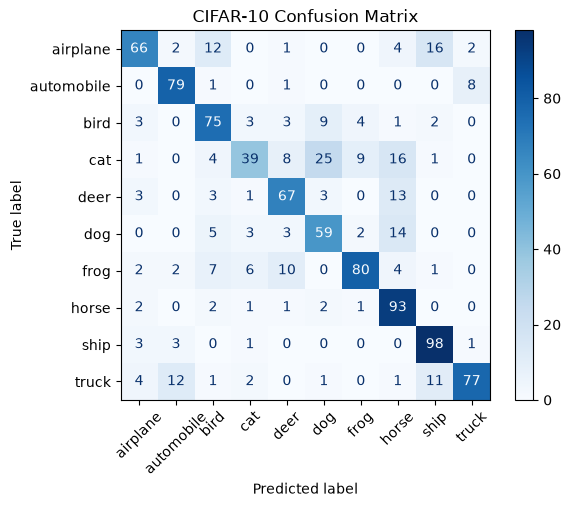

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("CIFAR-10 Confusion Matrix")
plt.show()

## Training and Validation Curves

Training and test loss and accuracy are plotted to visualize the model's learning performance across epochs.

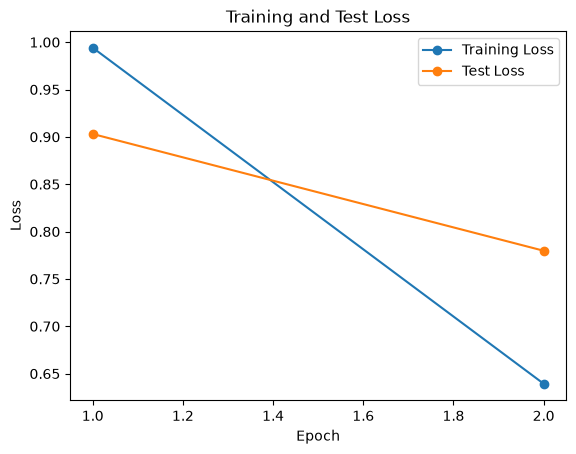

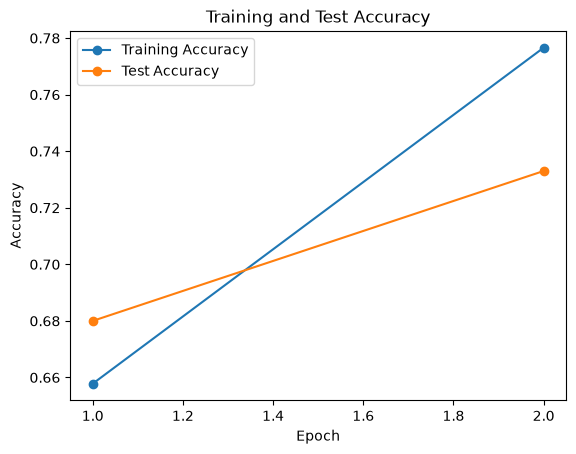

In [12]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure()
plt.plot(epochs, train_losses, marker="o", label="Training Loss")
plt.plot(epochs, test_losses, marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_accuracies, marker="o", label="Training Accuracy")
plt.plot(epochs, test_accuracies, marker="o", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.show()

## Model Inference

The saved model can be loaded and used to predict the class of a new CIFAR-10 image.

In [13]:
import torch
from PIL import Image

def predict_image(image_path):

    model.eval()

    image = Image.open(image_path).convert("RGB")

    image = test_transform(image)
    image = image.unsqueeze(0)
    image = image.to(device)

    with torch.no_grad():

        output = model(image)

        _, predicted = torch.max(output, 1)

    class_name = train_dataset.classes[predicted.item()]

    print("Predicted class:", class_name)

In [14]:
# Example:
# predict_image("path/to/your/image.jpg")

## Conclusion

A pretrained ResNet18 model was successfully fine-tuned for CIFAR-10 image classification using PyTorch.

Data augmentation was applied to the training dataset, and transfer learning was used to improve classification performance.

The model achieved approximately 73% test accuracy on the 1,000-image test subset.

The project also includes evaluation metrics, a confusion matrix, training curves, a saved model, and inference code.